# Questão 2
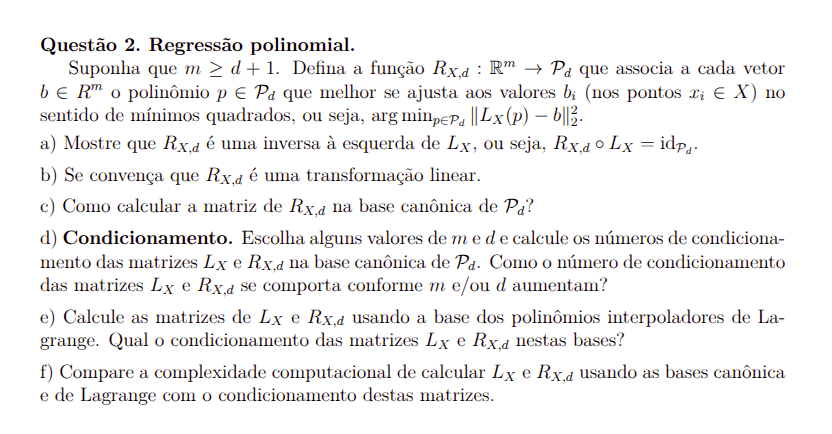

## Item a)

Para provarmos que a função $R_{X, d}$ é uma inversa à esquerda de $L_X$, vamos provar que a aplicação sucessiva dessas duas transformações a um polinômio $p$ retorna sempre o próprio $p$, ou seja, $R_{X, d}(L_X(p))=p$ $\forall p \in \mathcal{P}_d$


Seja $q$ um polinômio em $\mathcal{P}_d$. A transformação $L_X(q)$ nos retorna um vetor $b$ em $R^m$ tal que $b_i = q(x_i)$. 

$L_X(q) = b \implies ||L_X(p) - b||_2^2 = ||L_X(p) - L_X(q)||_2^2$

Como visto na questão 1, $L_X$ é linear e, então, $||L_X(p) - L_X(q)||_2^2 = ||L_X(p-q)||_2^2$

Sabemos que a norma é uma função não negativa, portanto $||L_X(p-q)||_2^2 \geq 0$, $ \forall p \in \mathcal{P}_d$.

Mas se $p=q$, temos $||L_X(p-q)||_2^2 = ||L_X(0)||_2^2 = ||0||_2^2 = 0$. 

Assim, $||L_X(q) - b||_2^2 \leq ||L_X(p) - b||_2^2$ $\forall p \in \mathcal{P}_d$

Como $m \geq d+1$, $L_X$ é "magra e alta" e, conforme questão anterior, tem posto cheio nas colunas. Portanto, o problema de mínimos quadrados tem solução única.

Desse modo, $q = arg min_{p \in P_d} ||L_X(p) - b||_2^2 = R_{X, d}(L_X(q))$

## Item b)

Nessa resolução, precisávamos de uma operação que fosse linear, diferente da norma! No caso, conseguimos desenvolver uma demonstração para $R_{X, d}(\alpha a) = R_{X, d}(a)$ usando diretamente o quadrado da norma, mas não conseguíamos usar a mesma estratégia para soma. Daí pensamos no produto interno!

Seja $R_{X, d}(a) = q_a, R_{X, d}(b)=q_b$

$q_a = argmin_{p \in \mathcal{P}_d}||L_X(p) - a||_2^2$ e sabemos, do curso de Álgebra linear, que $p$ é solução única de um problema de mínimos quadrados se e somente se a diferença entre $L_X(p)$ e $a$ é ortogonal ao espaço coluna de $L_X$. 

Temos, então, $ \langle L_X(q_a) - a, L_X(p) \rangle = 0$, $\forall p \in \mathcal{P}_d$. Analogamente, $ \langle L_X(q_b) - b, L_X(p) \rangle = 0$, $\forall p \in \mathcal{P}_d$

Multiplicando a segunda equação por um escalar $\alpha$ e somando, temos:

 $ \langle L_X(q_a) - a, L_X(p) \rangle + \alpha \langle L_X(q_b) - b, L_X(p) \rangle = 0$, $\forall p \in \mathcal{P}_d$  
 
 Pela linearidade do produto interno:

 $\langle L_X(q_a + \alpha q_b) - \alpha b - a, L_X(p) \rangle = 0$, $\forall p \in \mathcal{P}_d$

Mas então $q_a + \alpha q_b$ é solução para o problema de mínimos quadrados $argmin_{p \in \mathcal{P}_d}||L_X(p) - (a+ \alpha b)||_2^2 = R_{X, d}(a+ \alpha b)$

Assim, $R_{X, d}(a+ \alpha b) = R_{X, d}(a) + \alpha R_{X, d}(b)$, $\forall a, b \in R^m, \alpha \in R$


Provando a linearidade de $R_{X, d}$

## Item c)

Sabemos que a matriz $L$ que representa a transformação linear $L_X$ na base canônica de $\mathcal{P}_d$ é dada por uma matriz cujas colunas são o resultado de $L_X$ aplicada a cada polinômio $1, x, x^2, ..., x^d$.

Para obtermos a matriz $R$ que representa a transformação $R_{X, d}$, precisamos obter a solução, em mínimos quadrados, de $||L_X(p) - b||_2^2 = ||Lp - b||_2^2$. Como $L$ tem posto cheio nas colunas, sabemos que essa solução existe e é única!


Do curso de Álgebra Linear, sabemos que a solução é dada pela "pseudoinversa" $(L^T L)^{-1}L^T$ aplicada ao vetor $b$.

Assim, a transformação $R_{X, d}(b)$ equivale a multiplicar b à esquerda pela matriz $(L^T L)^{-1}L^T$. $R_{X, d}(b) = (L^T L)^{-1}L^Tb$, e então $R = (L^T L)^{-1}L^T$.



## Item d)

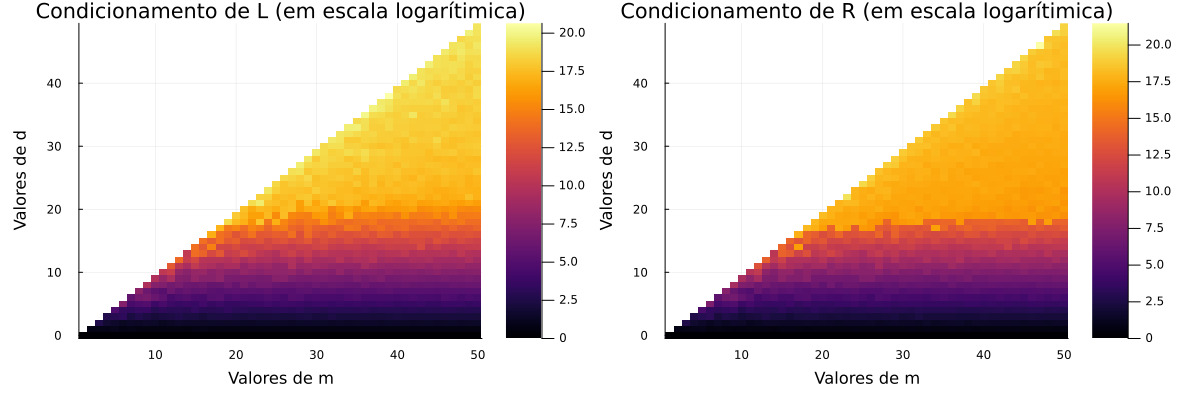

In [36]:
using LinearAlgebra: cond, pinv
using Plots

m = 50

condL = fill(NaN, m, m)
condR = fill(NaN, m, m)

for dim in 1:m
    for deg in 0:(dim - 1)
        X = rand(dim)
        L = [X[i]^j for i in 1:dim, j in 0:deg]
        R = pinv(L)
        condL[dim, deg + 1] = cond(L)
        condR[dim, deg + 1] = cond(R)
    end
end

p1 = heatmap(1:m, 0:(m - 1), log10.(condL)', left_margin = 8Plots.mm, bottom_margin = 8Plots.mm,
    xlabel = "Valores de m",
    ylabel = "Valores de d",
    title = "Condicionamento de L (em escala logarítimica)")
p2 = heatmap(1:m, 0:(m - 1), log10.(condR)',
    xlabel = "Valores de m",
    ylabel = "Valores de d",
    title = "Condicionamento de R (em escala logarítimica)")

plot(p1, p2, layout = (1, 2), size = (1200, 400))

## Item e)

A matriz de $L_x$ na base dos polinômios interpoladores de Lagrange será composta por colunas que são o resultado da aplicação da transformação  $L_x$ em cada vetor da base dos polinômios interpoladores de Lagrange. Convenientemente, ela terá formato $m \times d+1$ e será formada por um bloco de Identidade e um bloco de zeros!

$L = \begin{bmatrix} 1 & 0 & ... & 0 \\ 0 & 1 & ... & 0 \\ ... &... & & ... \\ 0 & 0 & ... & 1 \\ 0 & 0 & ... & 0\\ ...&...&&... \end{bmatrix} = \begin{bmatrix} I_{d+1} \\ 0 \end{bmatrix}$

Isso decorre da própria definição dos polinômios interpoladores de Lagrange.

Já a matriz $R$, dada por $(L^T L)^{-1}L^T$ será dada simplesmente por $ \begin{bmatrix} I_{d+1} & 0 \end{bmatrix}$

## Questão 3. Interpolação e Extrapolação.

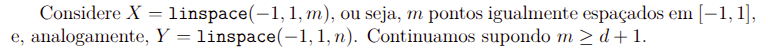

a) Qual o posto da aplicação composta LY ◦RX,d?


b) Explique porque a composta acima não depende da base escolhida para Pd.


c) Em que sentido esta composta é uma aplicação de interpolação?


d) Escolha alguns valores de m, n e d e calcule os valores singulares da composta, usando
como intermediárias tanto a base canônica quanto a base dos polinômios interpoladores de
Lagrange. Qual a diferença entre as matrizes calculadas?


e) Qual o condicionamento da composta LY ◦RX,d? Você pode fazer n →∞sem prejudicar
o condicionamento? E n →∞ e d →∞?


f) Refaça os exercícios (c) e (d) substituindo X pelo conjunto dos “pontos de Chebyshev”
xi = cos (2i−1 2m π)


g) Extrapolação 1. Considere X = linspace(−1,1,m), e Y = linspace(−1.5,1.5,n).
O que acontece agora?


h) Adianta usar os pontos de Chebyshev em X?


i) Extrapolação 2. Considere X = linspace(0,1,m), e Y = linspace(−1,0,n). O que
acontece agora? Adianta usar os pontos de Chebyshev?